<a href="https://colab.research.google.com/github/JTunnessen/mental_health_analysis/blob/main/v2_Mental_Health_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mental Health Sentiment Analysis

In [ ]:
import os
import re
import zipfile
import urllib.request
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics

import kagglehub

# ── Helper functions ─────────────────────────────────────────────────────────

def evaluate_model(model, loader, device):
    """Run inference on loader; return (pred_indices, true_labels) as CPU tensors."""
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for labels, inputs, lengths in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = torch.argmax(model(inputs, lengths), dim=1)
            all_pred.append(preds)
            all_true.append(labels)
    return torch.cat(all_pred).cpu(), torch.cat(all_true).cpu()


def print_metrics(true, pred, index_to_label, suffix=""):
    """Print accuracy and sklearn classification report."""
    label_str = f" ({suffix})" if suffix else ""
    accuracy = accuracy_score(true, pred)
    print(f"Overall Accuracy{label_str}: {accuracy:.4f}")
    target_names = [index_to_label[i] for i in sorted(index_to_label)]
    print(f"\nClassification Report{label_str}:\n")
    print(classification_report(true, pred, target_names=target_names))


def plot_confusion_matrix(true, pred, target_names, title="Confusion Matrix"):
    """Plot a seaborn confusion matrix heatmap."""
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()


Available device: cuda
Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-mental-health
Training statements shape: (37130, 1)
Training targets shape: (37130,)
Validation statements shape: (7956, 1)
Validation targets shape: (7956,)
Testing statements shape: (7957, 1)
Testing targets shape: (7957,)


In [ ]:
available_device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Available device: {available_device}")

# Download latest version - Mental Health Data
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")
print("Path to dataset files:", path)
mental_data = pd.read_csv(path + '/Combined Data.csv')

# Set the Target Data
targets = mental_data['status']

# Drop the target column to isolate the statements
statements = mental_data.drop('status', axis=1)
# Drop the first column of numbers (unnecessary index)
statements = statements.drop(mental_data.columns[0], axis=1)

# Split data into training set (70%) and temporary set (30%)
statements_train, statements_temp, targets_train, targets_temp = train_test_split(
    statements, targets, test_size=0.3, random_state=42)

# Split temporary set into validation set (15%) and testing set (15%)
statements_val, statements_test, targets_val, targets_test = train_test_split(
    statements_temp, targets_temp, test_size=0.5, random_state=42)

print(f"Training statements shape:   {statements_train.shape}")
print(f"Training targets shape:      {targets_train.shape}")
print(f"Validation statements shape: {statements_val.shape}")
print(f"Validation targets shape:    {targets_val.shape}")
print(f"Testing statements shape:    {statements_test.shape}")
print(f"Testing targets shape:       {targets_test.shape}")


## Prepare Validation and Test Data




In [ ]:

# --- Define clean_text_v2 function ---
def clean_text_v2(text):
  # Replace non-printable chars with space
  text = "".join(ch if ch.isprintable() else ' ' for ch in text)
  text = text.lower()
  # Regex to replace non-alphanumeric and non-whitespace characters with a space
  text = re.sub(r'[^\w\s]', ' ', text)
  # Collapse multiple spaces into one
  text = re.sub(r'\s+', ' ', text).strip()
  return text

# --- Rebuild Vocabulary and Label Mappings ---
all_words = set()
for sentence in statements_train['statement']:
    if isinstance(sentence, str):
        cleaned = clean_text_v2(sentence)
        words = cleaned.split()
        for w in words:
            all_words.add(w)

word_to_index = {"<PAD>": 0, "<UNK>": 1}
idx = 2
for word in sorted(list(all_words)):
  word_to_index[word] = idx
  idx += 1

label_to_index = {}
for label in sorted(list(set(targets_train))): # Use targets_train for labels
    if label not in label_to_index:
      label_to_index[label] = len(label_to_index)

# --- Determine max_len from training data ---
tokenized_numerical_sequences_train = []
for sentence in statements_train['statement']:
    if isinstance(sentence, str):
        cleaned = clean_text_v2(sentence)
        words = cleaned.split()
        numerical_seq = [word_to_index.get(word, word_to_index["<UNK>"]) for word in words]
        tokenized_numerical_sequences_train.append(numerical_seq)
    else:
        tokenized_numerical_sequences_train.append([word_to_index["<UNK>"]])

max_len = max(len(s) for s in tokenized_numerical_sequences_train)


# --- Prepare Training Data ---
#Convert string labels to integer labels
labels_train_int = [label_to_index[label] for label in targets_train]

#Pad and Truncate for training data
padded_sequences_train = []
for seq in tokenized_numerical_sequences_train:
    if len(seq) > max_len:
        padded_seq = seq[:max_len]
    else:
        padded_seq = seq + [word_to_index["<PAD>"]] * (max_len - len(seq))
    padded_sequences_train.append(padded_seq)

# Convert to PyTorch Tensors
input_tensor_train = torch.tensor(padded_sequences_train, dtype=torch.long)
label_tensor_train = torch.tensor(labels_train_int, dtype=torch.long)


# --- Prepare Validation Data ---#
#Convert string labels to integer labels
labels_val_int = [label_to_index[label] for label in targets_val] # Use global label_to_index

#Tokenize
tokenize_statements_val = []
for sentence in statements_val['statement']:
    if isinstance(sentence, str):
        sentence = clean_text_v2(sentence) # Apply the cleaning function
        tokens = [word_to_index.get(word, word_to_index["<UNK>"]) for word in sentence.split()]
        tokenize_statements_val.append(tokens)
    else:
        tokenize_statements_val.append([word_to_index["<UNK>"]]) # Handle NaN or non-string values

#Pad and Truncate
padded_sequences_val = []
for seq in tokenize_statements_val:
    if len(seq) > max_len:
        padded_seq = seq[:max_len] # Truncate if sequence is longer than max_len
    else:
        padded_seq = seq + [word_to_index["<PAD>"]] * (max_len - len(seq))
    padded_sequences_val.append(padded_seq)

# Convert to PyTorch Tensors
input_tensor_val = torch.tensor(padded_sequences_val, dtype=torch.long)
label_tensor_val = torch.tensor(labels_val_int, dtype=torch.long)

# --- Prepare Testing Data ---
#Convert string labels to integer labels
labels_test_int = [label_to_index[label] for label in targets_test] # Use global label_to_index

#Tokenize
tokenize_statements_test = []
for sentence in statements_test['statement']:
    if isinstance(sentence, str):
        sentence = clean_text_v2(sentence) # Apply the cleaning function
        tokens = [word_to_index.get(word, word_to_index["<UNK>"]) for word in sentence.split()]
        tokenize_statements_test.append(tokens)
    else:
        tokenize_statements_test.append([word_to_index["<UNK>"]]) # Handle NaN or non-string values

#Pad and Truncate
padded_sequences_test = []
for seq in tokenize_statements_test:
    if len(seq) > max_len:
        padded_seq = seq[:max_len] # Truncate if sequence is longer than max_len
    else:
        padded_seq = seq + [word_to_index["<PAD>"]] * (max_len - len(seq))
    padded_sequences_test.append(padded_seq)

# Convert to PyTorch Tensors
input_tensor_test = torch.tensor(padded_sequences_test, dtype=torch.long)
label_tensor_test = torch.tensor(labels_test_int, dtype=torch.long)

print(f"Input training tensor shape: {input_tensor_train.shape}")
print(f"Label training tensor shape: {label_tensor_train.shape}")
print(f"Input validation tensor shape: {input_tensor_val.shape}")
print(f"Label validation tensor shape: {label_tensor_val.shape}")
print(f"Input testing tensor shape: {input_tensor_test.shape}")
print(f"Label testing tensor shape: {label_tensor_test.shape}")

Input training tensor shape: torch.Size([37130, 5259])
Label training tensor shape: torch.Size([37130])
Input validation tensor shape: torch.Size([7956, 5259])
Label validation tensor shape: torch.Size([7956])
Input testing tensor shape: torch.Size([7957, 5259])
Label testing tensor shape: torch.Size([7957])


In [ ]:
# --- GloVe download and parse functions ---
def download_and_unzip_glove(dest_folder: str) -> str:
  glove_zip = os.path.join(dest_folder, "glove.2024.dolma.300d.zip")
  glove_txt = os.path.join(dest_folder, "dolma_300_2024_1.2M.100_combined.txt")

  print(f"Checking for GloVe file at: {glove_txt}")
  if os.path.exists(glove_txt):
    print(f"GloVe file already exists at: {glove_txt}")
    return glove_txt

  print("GloVe file not found. Attempting download and unzip...")
  print("Downloading GloVe... this may take a while.")
  if not os.path.exists(dest_folder):
    os.makedirs(dest_folder)

  url = "https://nlp.stanford.edu/data/wordvecs/glove.2024.dolma.300d.zip"
  try:
    urllib.request.urlretrieve(url, glove_zip)
    print("Download complete. Unzipping...")
    with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
      zip_ref.extractall(dest_folder)
    print("Unzip complete.")
    os.remove(glove_zip)

    if not os.path.exists(glove_txt):
      raise FileNotFoundError("GloVe txt file not found after extraction.")

  except Exception as e:
    print(f"An error occurred during download/unzip: {e}")
    return ""

  print(f"GloVe file ready at: {glove_txt}")
  return glove_txt

def load_glove_vectors(glove_file_path: str, embedding_dim: int = 300) -> Dict[str, np.ndarray]:
    print(f"Loading GloVe vectors from {glove_file_path}...")
    embeddings_index = {}
    corrupted_lines = 0
    try:
        with open(glove_file_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f):
                values = line.split()

                if len(values) < embedding_dim + 1:
                    corrupted_lines += 1
                    continue

                word = values[0]

                try:
                    vector_part = values[-embedding_dim:]

                    if len(vector_part) != embedding_dim:
                        corrupted_lines += 1
                        continue

                    coefs = np.asarray(vector_part, dtype='float32')
                    embeddings_index[word] = coefs

                except ValueError:
                    corrupted_lines += 1
                    pass
    except FileNotFoundError:
        print(f"Error: File not found at {glove_file_path}.")
        print("Please download the GloVe embeddings first.")
        print("You can get 'glove.6B.100d.txt' from: httpss://nlp.stanford.edu/projects/glove/")
        return {}

    print(f"Found {len(embeddings_index)} word vectors.")
    if corrupted_lines > 0:
        print(f"Skipped {corrupted_lines} corrupted/malformed lines.")
    return embeddings_index

# --- Simulate GloVe as a Fallback ---
def simulate_glove_vectors(vocab: List[str], embedding_dim: int) -> Dict[str, np.ndarray]:
    print("--- SIMULATING GloVe vector loading ---")
    fake_glove = {}
    for word in vocab:
        if word not in ["<PAD>", "<UNK>"]:
            if np.random.rand() > 0.1:
                fake_glove[word] = np.random.rand(embedding_dim).astype(np.float32)
    fake_glove["the"] = np.random.rand(embedding_dim).astype(np.float32)
    fake_glove["a"] = np.random.rand(embedding_dim).astype(np.float32)
    print(f"Simulated finding {len(fake_glove)} word vectors.")
    print("--- End of Simulation ---")
    return fake_glove

# --- Attention class ---
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        attn_weights = self.attention(lstm_output)
        attn_weights = torch.softmax(attn_weights, dim=1)
        weighted_output = lstm_output * attn_weights
        context_vector = torch.sum(weighted_output, dim=1)
        return context_vector, attn_weights

class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after a given patience.
    """
    def __init__(self, patience=3, verbose=False, delta=0, path='checkpoint.pt'):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 3
            verbose (bool): If True, prints a message for each validation loss improvement.
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pt'
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf # Corrected: np.inf instead of np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# --- ClassificationRNN class ---
class ClassificationRNN(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix, dropout=0.5):
    super(ClassificationRNN, self).__init__()

    self.hidden_dim = hidden_dim
    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
    self.embedding.weight.requires_grad = False
    self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, num_layers=2)
    self.attention = Attention(hidden_dim)
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(hidden_dim, num_classes)

  def forward(self, text, text_lengths):
    embedded = self.embedding(text)
    packed_embedded = pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False)
    packed_output, (hidden, cell) = self.lstm(packed_embedded)
    lstm_output, _ = torch.nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
    context_vector, attn_weights = self.attention(lstm_output)
    dropped_out_context = self.dropout(context_vector)
    out = self.fc(dropped_out_context)
    return out

# --- Collate_batch function ---
def collate_batch(batch):
    label_list, text_list, length_list = [], [], []

    for (_label, _text) in batch:
        label_list.append(_label)
        text_list.append(_text)
        length_list.append(len(_text))

    text_padded = pad_sequence(text_list, batch_first=True, padding_value=0)

    return (
        torch.tensor(label_list),
        text_padded,
        torch.tensor(length_list)
    )

# --- Derive vocab_size and num_classes from available kernel state ---
vocab_size = len(word_to_index)
num_classes = len(label_to_index)

#Load GloVe & Build Embedding Matrix
EMBEDDING_DIM = 300 # match the downloaded GloVe 300d file

GLOVE_DATA_DIR = "/content/drive/MyDrive/Data"

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
  from google.colab import drive
  drive.mount('/content/drive')

glove_file = download_and_unzip_glove(GLOVE_DATA_DIR)
print(f"Value of glove_file after calling download_and_unzip_glove: {glove_file}")

if not os.path.exists(glove_file):
        print(f"Error: GloVe file not found at {glove_file}")
        print("\nPlease download it from https://nlp.stanford.edu/projects/glove/")
        print(f"\nOr try uncommenting the 'download_and_unzip_glove' line in the script.")
        # As a fallback, use the simulation
        print("\n--- FALLING BACK TO SIMULATION ---")
        glove_embeddings = simulate_glove_vectors(list(word_to_index.keys()), EMBEDDING_DIM)
else:
        # STEP 2: Load the REAL GloVe vectors
        glove_embeddings = load_glove_vectors(glove_file, EMBEDDING_DIM) # Pass EMBEDDING_DIM here
        if not glove_embeddings:
            print("Error loading GloVe vectors. Exiting.")
            glove_embeddings = simulate_glove_vectors(list(word_to_index.keys()), EMBEDDING_DIM)

embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, EMBEDDING_DIM))
embedding_matrix[word_to_index["<PAD>"]] = np.zeros(EMBEDDING_DIM)

words_found = 0
for word, index in word_to_index.items():
    if index == 0: continue
    vector = glove_embeddings.get(word)
    if vector is not None:
      embedding_matrix[index] = vector
      words_found += 1

print(f"\nTotal words found: {words_found} / {vocab_size} words from GloVe into embedding matrix.")

    #Initialize Model
    #Hyperparameters
HIDDEN_DIM = 512
BATCH_SIZE = 256
LEARNING_RATE = 0.001
MAX_GRAD_NORM = 1.0 # Max norm for gradient clipping
    #OUTPUT_DIM is now num_classes

    #Instantiate the Model
model = ClassificationRNN(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, num_classes, embedding_matrix)
model.to(available_device) # Move model to GPU if available

    #Print the number of trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nNumber of trainable parameters: {trainable_params}")

# Calculate weights for imbalanced classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(targets_train),
    y=targets_train
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(available_device)

    #Define and Load Optimizer
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=1e-5)

print(f"\nModel architecture:\n{model}")
print(f"\nLoss function:\n{criterion}")
print(f"\nOptimizer:\n{optimizer}")

    #Create a Dataloader for training data
# Convert tokenized_numerical_sequences_train to list of tensors for collate_batch
train_dataset = []
for i, seq in enumerate(tokenized_numerical_sequences_train):
    train_dataset.append((label_tensor_train[i], torch.tensor(seq, dtype=torch.long)))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)

# Create a DataLoader for validation data
val_dataset = []
for i, seq in enumerate(tokenize_statements_val):
    val_dataset.append((label_tensor_val[i], torch.tensor(seq, dtype=torch.long)))

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

# Create a DataLoader for test data
test_dataset = []
for i, seq in enumerate(tokenize_statements_test):
    test_dataset.append((label_tensor_test[i], torch.tensor(seq, dtype=torch.long)))

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

early_stopping = EarlyStopping(patience=3, verbose=True, path='best_depression_model.pt')
    #Training Loop
num_epochs = 10
print("\nStarting training loop...")

epoch_losses = [] # Initialize list to store losses

for epoch in range(num_epochs):
      model.train()

      epoch_loss = 0.0

      #Iterate over batches from the DataLoader
      for labels, text, text_lengths in train_loader:
          labels = labels.to(available_device) # Move labels to GPU
          text = text.to(available_device) # Move inputs to GPU

          optimizer.zero_grad()
          predictions = model(text, text_lengths)
          loss = criterion(predictions, labels)

      #backward Pass
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM) # Gradient clipping
          optimizer.step()

          epoch_loss += loss.item()

      # Print training loss for the epoch
      train_loss = epoch_loss / len(train_loader)
      epoch_losses.append(train_loss)

      # --- Validation Step ---
      model.eval()  # Switch to eval mode (turns off dropout)
      val_loss = 0
      correct = 0
      with torch.no_grad():
          for val_labels, val_text, val_lengths in val_loader: # Uses the new val_loader
              val_labels = val_labels.to(available_device)
              val_text = val_text.to(available_device)

              outputs = model(val_text, val_lengths)
              loss = criterion(outputs, val_labels)
              val_loss += loss.item()

              # Calculate accuracy
              _, predicted = torch.max(outputs.data, 1)
              correct += (predicted == val_labels).sum().item()

      avg_val_loss = val_loss / len(val_loader)
      accuracy = 100 * correct / len(val_dataset)

      print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {accuracy:.2f}%')

      # --- Early Stopping Call ---
      early_stopping(val_loss, model)

      if early_stopping.early_stop:
        print("Early stopping triggered. Stop training to prevent overfitting.")
        break

# --- Load Best Model ---
# After the loop, load the state dict of the best model found
model.load_state_dict(torch.load('best_depression_model.pt'))

model.train() # Switch back to train mode

print("\nTraining finished. Running predictions...")

Checking for GloVe file at: /content/drive/MyDrive/Data/dolma_300_2024_1.2M.100_combined.txt
GloVe file already exists at: /content/drive/MyDrive/Data/dolma_300_2024_1.2M.100_combined.txt
Value of glove_file after calling download_and_unzip_glove: /content/drive/MyDrive/Data/dolma_300_2024_1.2M.100_combined.txt
Loading GloVe vectors from /content/drive/MyDrive/Data/dolma_300_2024_1.2M.100_combined.txt...
Found 1200001 word vectors.

Total words found: 39588 / 49077 words from GloVe into embedding matrix.

Number of trainable parameters: 3772424

Model architecture:
ClassificationRNN(
  (embedding): Embedding(49077, 300)
  (lstm): LSTM(300, 512, num_layers=2, batch_first=True)
  (attention): Attention(
    (attention): Linear(in_features=512, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=7, bias=True)
)

Loss function:
CrossEntropyLoss()

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999

## Prediction and Evaluation




In [ ]:
index_to_label = {v: k for k, v in label_to_index.items()}
target_names = [index_to_label[i] for i in sorted(index_to_label)]

all_pred_indices, all_true_labels = evaluate_model(model, test_loader, available_device)
print(f"Total predictions made: {len(all_pred_indices)}")


Total predictions made: 7957


In [ ]:
print_metrics(all_true_labels, all_pred_indices, index_to_label)


Overall Accuracy: 0.7597

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.75      0.90      0.82       570
             Bipolar       0.84      0.77      0.81       414
          Depression       0.86      0.50      0.63      2313
              Normal       0.92      0.91      0.91      2492
Personality disorder       0.48      0.70      0.57       180
              Stress       0.53      0.79      0.63       401
            Suicidal       0.61      0.86      0.71      1587

            accuracy                           0.76      7957
           macro avg       0.71      0.77      0.73      7957
        weighted avg       0.79      0.76      0.76      7957



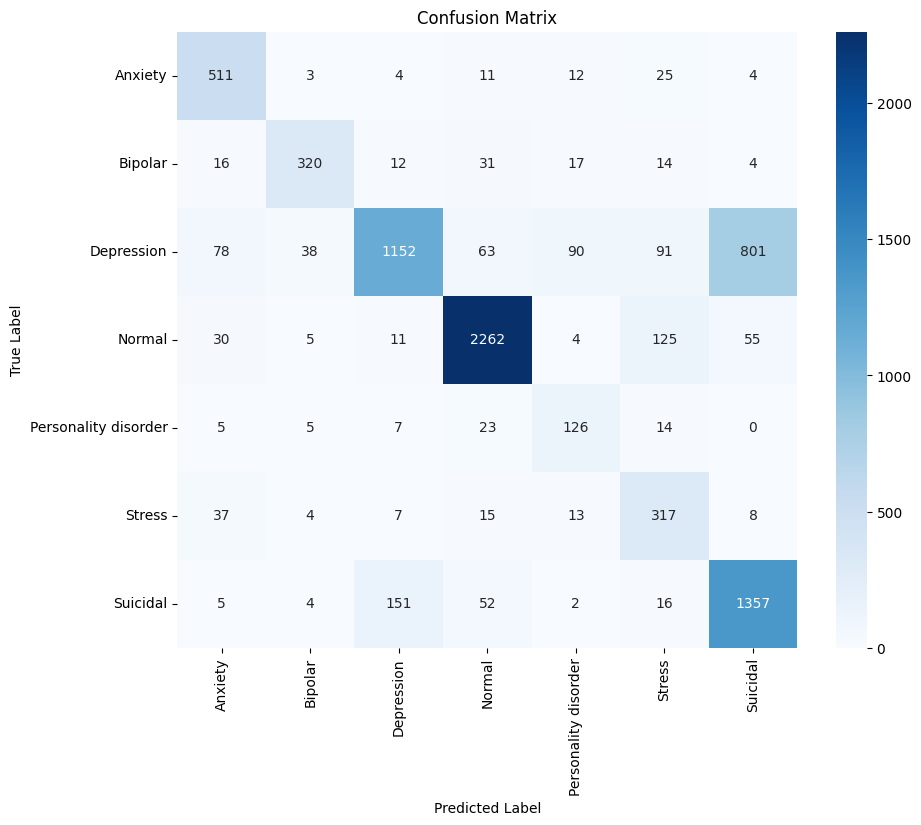

In [ ]:
plot_confusion_matrix(all_true_labels, all_pred_indices, target_names)


## Fine-tuning the model

In [ ]:
# --- PHASE 2 CONFIGURATION ---

# 1. Unfreeze the Embeddings
# Unlock the 49,077 vectors for updating.
model.embedding.weight.requires_grad = True

# 2. LOWER The Learning Rate
# Drop from 0.001 to 0.0001.
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# 3. Define Phase 2 Loop
fine_tune_epochs = 10

print(f"--- Starting Phase 2: Fine-Tuning for {fine_tune_epochs} epochs ---")
print("Goal: Separate 'Depression' from 'Suicidal' vectors.")

early_stopping = EarlyStopping(patience=3, verbose=True, path='best_depression_model.pt')

# --- RESUME TRAINING LOOP ---
for epoch in range(1, fine_tune_epochs + 1):
    model.train()
    train_loss = 0

    for labels, text, text_lengths in train_loader:
        labels = labels.to(available_device)
        text = text.to(available_device)

        optimizer.zero_grad()

        predictions = model(text, text_lengths)
        loss = criterion(predictions, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --- VALIDATION (CRITICAL) ---
    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for val_labels, val_text, val_lengths in val_loader:
            val_labels = val_labels.to(available_device)
            val_text = val_text.to(available_device)

            outputs = model(val_text, val_lengths)
            v_loss = criterion(outputs, val_labels)
            val_loss += v_loss.item()

            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == val_labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    acc = 100 * correct / len(val_dataset)

    print(f'Phase 2 Epoch {epoch}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.2f}%')

    # --- Early Stopping Call ---
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered. Stop training to prevent overfitting.")
        break

# --- Load Best Model ---
# After the loop, load the state dict of the best model found
model.load_state_dict(torch.load('best_depression_model.pt'))


--- Starting Phase 2: Fine-Tuning for 10 epochs ---
Goal: Separate 'Depression' from 'Suicidal' vectors.
Phase 2 Epoch 1: Train Loss: 0.5060 | Val Loss: 0.6171 | Val Acc: 75.01%
Validation loss decreased (inf --> 19.748789).  Saving model ...
Phase 2 Epoch 2: Train Loss: 0.4767 | Val Loss: 0.6197 | Val Acc: 76.02%
EarlyStopping counter: 1 out of 3
Phase 2 Epoch 3: Train Loss: 0.4617 | Val Loss: 0.6242 | Val Acc: 76.07%
EarlyStopping counter: 2 out of 3
Phase 2 Epoch 4: Train Loss: 0.4335 | Val Loss: 0.6315 | Val Acc: 76.42%
EarlyStopping counter: 3 out of 3
Early stopping triggered. Stop training to prevent overfitting.


<All keys matched successfully>

In [ ]:
all_pred_indices, all_true_labels = evaluate_model(model, test_loader, available_device)
print(f"Total predictions made: {len(all_pred_indices)}")


Total predictions made: 7957


In [ ]:
print_metrics(all_true_labels, all_pred_indices, index_to_label, suffix="After Fine-Tuning")


Overall Accuracy (After-fine Tuning): 0.7647

Classification Report (After-fine Tuning):

                      precision    recall  f1-score   support

             Anxiety       0.81      0.86      0.84       570
             Bipolar       0.77      0.79      0.78       414
          Depression       0.84      0.54      0.66      2313
              Normal       0.93      0.90      0.92      2492
Personality disorder       0.45      0.76      0.57       180
              Stress       0.51      0.79      0.62       401
            Suicidal       0.63      0.83      0.71      1587

            accuracy                           0.76      7957
           macro avg       0.71      0.78      0.73      7957
        weighted avg       0.80      0.76      0.76      7957



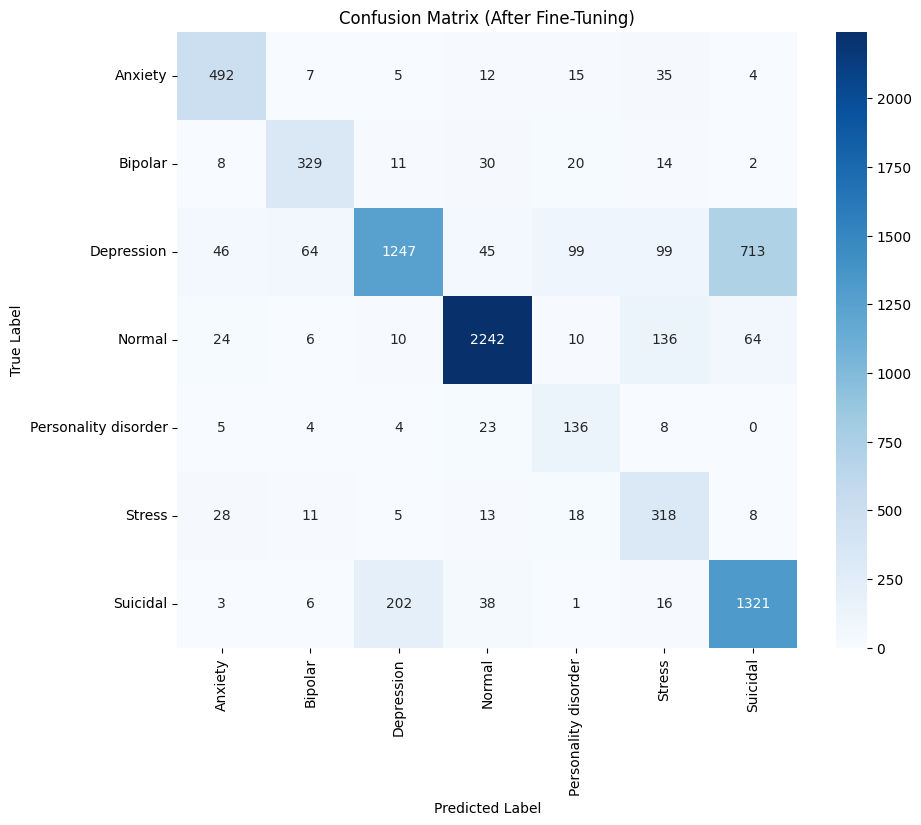

In [ ]:
plot_confusion_matrix(all_true_labels, all_pred_indices, target_names, title="Confusion Matrix (After Fine-Tuning)")


Real-world Inference

In [ ]:
def predict_sentiment(sentence, model, word_to_idx, idx_to_label):
    model.eval()

    # 1. Tokenize (matching data prep using clean_text_v2)
    cleaned = clean_text_v2(sentence) # Use the cleaning function
    tokens = cleaned.split()

    # 2. Convert to Indices
    token_indices = []
    for token in tokens:
        if token in word_to_idx:
            token_indices.append(word_to_idx[token])
        else:
            token_indices.append(word_to_idx["<UNK>"]) # Use UNK for unknown words

    # 3. Pad or Truncate
    length = len(token_indices)
    if length == 0:
        return "Error: No known words in input.", 0.0 # Return 0 confidence for empty input

    # Use the global max_len determined from training data
    if length > max_len:
        token_indices = token_indices[:max_len]
        length = max_len
    else:
        # Pad with zeros (assuming padding_idx=0)
        token_indices += [word_to_idx["<PAD>"]] * (max_len - length)

    # 4. Convert to Tensor
    # Shape: [1, max_len] (Batch size of 1)
    tensor_input = torch.LongTensor([token_indices]).to(available_device) # Use available_device
    tensor_length = torch.LongTensor([length]) # CPU tensor for packing

    # 5. Predict
    with torch.no_grad():
        # Forward pass
        output = model(tensor_input, tensor_length)

        # Get Probabilities
        probs = F.softmax(output, dim=1)

        # Get Top Prediction
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    predicted_label = idx_to_label[pred_idx]

    return predicted_label, confidence

# --- DEFINE LABEL MAP ---
idx_to_label = index_to_label

# --- TEST IT ---
test_sentences = [
    "I feel completely hopeless and I want to end it all.",
    "I had a great day at the park today!",
    "I can't sleep because I'm so worried about my exam tomorrow.",
    "I feel so sad and empty, like nothing matters anymore.",
    "My mood swings are out of control, one minute I'm up, the next I'm down."
]

print(f"{'SENTENCE':<60} | {'PREDICTION':<20} | {'CONFIDENCE'}")
print("-" * 95)

for sent in test_sentences:
    # Pass word_to_index instead of vocab
    label, conf = predict_sentiment(sent, model, word_to_index, idx_to_label)
    print(f"{sent[:58]:<60} | {label:<20} | {conf:.4f}")


SENTENCE                                                     | PREDICTION           | CONFIDENCE
-----------------------------------------------------------------------------------------------
I feel completely hopeless and I want to end it all.         | Suicidal             | 0.5696
I had a great day at the park today!                         | Normal               | 0.9982
I can't sleep because I'm so worried about my exam tomorro   | Anxiety              | 0.9826
I feel so sad and empty, like nothing matters anymore.       | Suicidal             | 0.5671
My mood swings are out of control, one minute I'm up, the    | Bipolar              | 0.5398


## Explainable AI

In [ ]:
# 1. Redefine the Class to return attention weights
class ClassificationRNN_Viz(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, padding_idx=0):
        super(ClassificationRNN_Viz, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.5)
        self.attention = Attention(hidden_dim) # Uses existing Attention class
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)
        packed_embedded = pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, _ = self.lstm(packed_embedded)
        output, _ = torch.nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)

        # Capture the weights here
        context_vector, attn_weights = self.attention(output)

        context_vector = self.dropout(context_vector)
        prediction = self.fc(context_vector)

        # RETURN BOTH
        return prediction, attn_weights

# 2. Transfer weights from trained 'model' to 'viz_model'
# Use the same hyperparameters as your current model
viz_model = ClassificationRNN_Viz(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, num_classes).to(available_device) # Adjusted vocab_size to match the trained model
viz_model.load_state_dict(model.state_dict()) # Copy trained weights
viz_model.eval()
print("Visualization Model Ready.")

Visualization Model Ready.


Generating Attention Heatmaps...


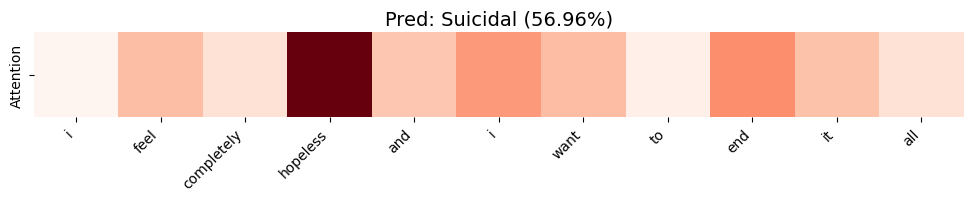

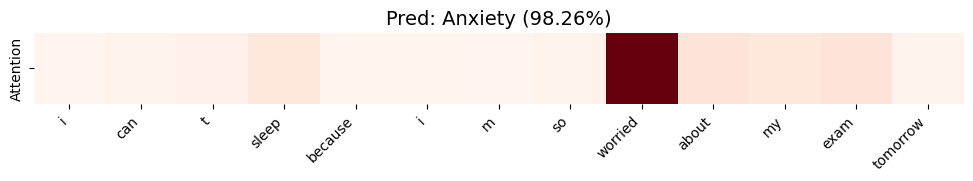

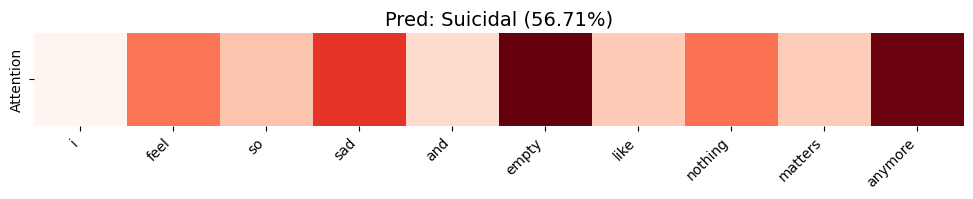

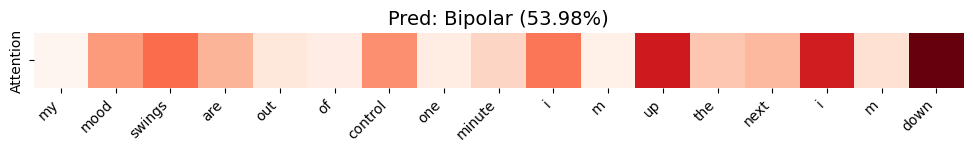

In [ ]:
def plot_attention(sentence, model, word_to_idx, idx_to_label): # Removed max_len=300 from signature, uses global max_len
    model.eval() # Use the passed model, not a global viz_model

    # 1. Tokenize & Prepare (matching predict_sentiment)
    cleaned = clean_text_v2(sentence) # Use the cleaning function
    tokens = cleaned.split()

    token_indices = []
    for token in tokens:
        if token in word_to_idx:
            token_indices.append(word_to_idx[token])
        else:
            token_indices.append(word_to_idx["<UNK>"]) # Use UNK for unknown words

    length = len(token_indices)
    if length == 0:
        print(f"Warning: No known words in input for sentence: '{sentence}'. Skipping plot.")
        return # Cannot plot if no tokens

    # Use the global max_len determined from training data
    if length > max_len:
        token_indices = token_indices[:max_len]
        length = max_len
    else:
        # Pad with zeros (assuming padding_idx=0 for <PAD>)
        token_indices += [word_to_index["<PAD>"]] * (max_len - length) # Uses global word_to_index

    tensor_input = torch.LongTensor([token_indices]).to(available_device)
    tensor_length = torch.LongTensor([length]) # This length is important for pack_padded_sequence

    # 2. Get Prediction AND Attention Weights
    with torch.no_grad():
        output, attn_weights = model(tensor_input, tensor_length)
        probs = F.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()
        predicted_label = idx_to_label[pred_idx]

    # 3. Process Weights for Plotting
    # attn_weights shape: [1, seq_len, 1] -> flatten to [seq_len]
    # Take only the weights corresponding to the actual tokens before padding
    weights = attn_weights.squeeze().cpu().numpy()
    weights = weights[:len(tokens)] # Use the original number of tokens for visualization

    # If the sentence is short, weights might be a scalar or 0-d array (edge case)
    if weights.ndim == 0: weights = [weights]

    # Resize for visual clarity (Matrix shape: 1 row x N words)
    weights = weights.reshape(1, -1)

    # 4. Plot
    plt.figure(figsize=(12, 2))
    sns.heatmap(weights, xticklabels=tokens, yticklabels=['Attention'],
                cmap='Reds', annot=False, cbar=False, square=True)
    plt.title(f"Pred: {predicted_label} ({confidence:.2%})", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.show()

# --- RUN THE VISUALIZATION ---
# Re-running the visualization with the corrected plot_attention function
test_sentences = [
    "I feel completely hopeless and I want to end it all.",
    "I can't sleep because I'm so worried about my exam tomorrow.",
    "I feel so sad and empty, like nothing matters anymore.",
    "My mood swings are out of control, one minute I'm up, the next I'm down."
]

print("Generating Attention Heatmaps...")
for sent in test_sentences:
    plot_attention(sent, viz_model, word_to_index, idx_to_label)